In [1]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from scipy import stats
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

RESULTS_DIR = (Path.cwd().parent / "data" / "results").resolve()
if not (RESULTS_DIR / "nn_results_fp16.json").exists():
    # fallback when cwd is repo root
    RESULTS_DIR = Path("experiment/data/results").resolve()

CONDITIONS = ["fp16", "int8", "nf4"]
CONDITION_LABELS = {"fp16": "FP16", "int8": "INT8", "nf4": "NF4"}
COLORS = {"fp16": "#2563eb", "int8": "#16a34a", "nf4": "#dc2626"}


def load_results(results_dir: Path = RESULTS_DIR) -> dict[str, list[dict]]:
    out = {}
    for cond in CONDITIONS:
        path = results_dir / f"nn_results_{cond}.json"
        with open(path) as f:
            out[cond] = json.load(f)
        print(f"{cond:>5}: {len(out[cond]):>4} rows  ←  {path.name}")
    return out


def rows_to_df(rows: list[dict], condition: str) -> pd.DataFrame:
    """One row per (val_idx, layer) with aggregated neighbor stats."""
    records = []
    for r in rows:
        top5 = r["top5_results"]
        depths = [n["min_depth"] for n in top5 if n.get("min_depth") is not None]
        sims = [n["similarity"] for n in top5]
        nouns = [n for n in top5 if n.get("is_noun") and n.get("min_depth") is not None]

        top1 = top5[0] if top5 else {}
        top1_noun = next((n for n in top5 if n.get("is_noun")), None)

        records.append({
            "condition": condition,
            "val_idx": r["val_idx"],
            "layer": r["layer"],
            "key": (r["val_idx"], r["layer"]),
            "top1_word": top1.get("full_word", ""),
            "top1_sim": top1.get("similarity"),
            "top1_depth": top1.get("min_depth"),
            "top1_nn_layer": top1.get("nn_layer"),
            "top1_noun_word": top1_noun.get("full_word") if top1_noun else None,
            "top1_noun_depth": top1_noun.get("min_depth") if top1_noun else None,
            "mean_depth": float(np.mean(depths)) if depths else np.nan,
            "n_valid_depth": len(depths),
            "mean_sim": float(np.mean(sims)) if sims else np.nan,
            "top5_words": tuple(n.get("full_word", "") for n in top5),
            "top5_nn_layers": tuple(n.get("nn_layer") for n in top5),
        })
    return pd.DataFrame.from_records(records)


results = load_results()
dfs = {c: rows_to_df(results[c], c) for c in CONDITIONS}

# sanity: paired keys should match across conditions
keys_fp16 = set(dfs["fp16"]["key"])
for c in CONDITIONS:
    assert set(dfs[c]["key"]) == keys_fp16, f"key mismatch for {c}"
print(f"\nPaired rows: {len(keys_fp16)}  |  layers: {sorted(dfs['fp16']['layer'].unique())}")

Matplotlib is building the font cache; this may take a moment.


 fp16:  800 rows  ←  nn_results_fp16.json
 int8:  800 rows  ←  nn_results_int8.json
  nf4:  800 rows  ←  nn_results_nf4.json

Paired rows: 800  |  layers: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(24), np.int64(26), np.int64(27)]


In [2]:
def summary_table(dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for cond, df in dfs.items():
        rows.append({
            "condition": CONDITION_LABELS[cond],
            "n_rows": len(df),
            "mean_top1_sim": df["top1_sim"].mean(),
            "mean_depth (top5)": df["mean_depth"].mean(),
            "coverage (% w/ depth)": 100 * (df["n_valid_depth"] > 0).mean(),
            "top1 exact match vs fp16": np.nan,
            "top1 noun depth mean": df["top1_noun_depth"].mean(),
        })
    out = pd.DataFrame(rows).set_index("condition")

    fp = dfs["fp16"].set_index("key")
    for cond in ("int8", "nf4"):
        q = dfs[cond].set_index("key")
        match = (fp["top1_word"] == q["top1_word"]).mean()
        out.loc[CONDITION_LABELS[cond], "top1 exact match vs fp16"] = 100 * match
    return out


display(summary_table(dfs).round(3))

,n_rows,mean_top1_sim,mean_depth (top5),coverage (% w/ depth),top1 exact match vs fp16,top1 noun depth mean
condition,,,,,,
FP16,800,0.306,7.346,57.375,NaN,7.347
INT8,800,0.307,7.359,56.375,91.375,7.360
NF4,800,0.303,7.320,56.875,81.250,7.307


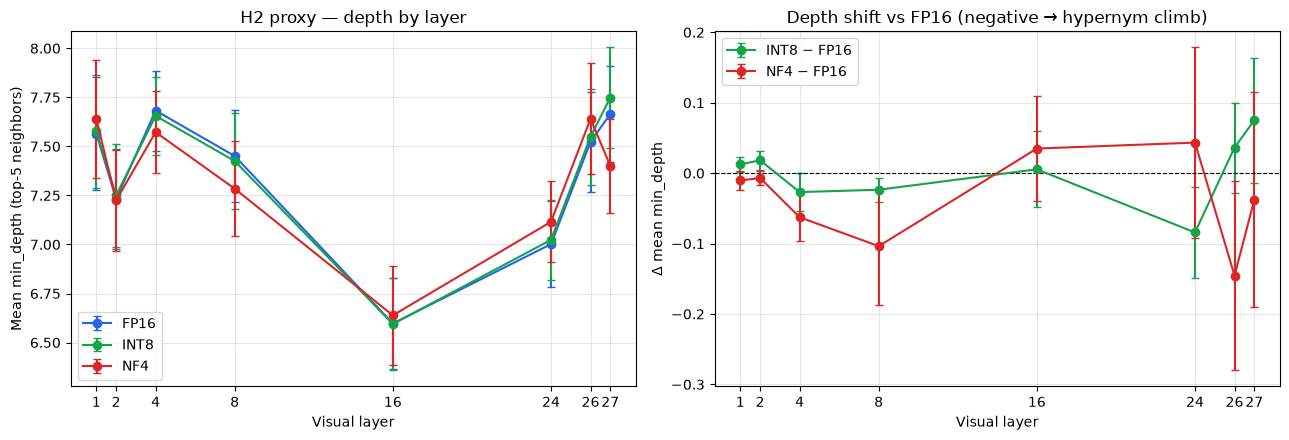

Saved → /Users/praful/myfiles/repos/latentlens/experiment/data/results/eda_depth_by_layer.png


In [3]:
# H2: mean WordNet min_depth (top-5) per visual layer — lower = more hypernym-like

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

layers = sorted(dfs["fp16"]["layer"].unique())

# left: absolute curves
ax = axes[0]
for cond in CONDITIONS:
    by_layer = dfs[cond].groupby("layer")["mean_depth"].agg(["mean", "sem"])
    ax.errorbar(
        by_layer.index, by_layer["mean"], yerr=by_layer["sem"],
        marker="o", capsize=3, label=CONDITION_LABELS[cond], color=COLORS[cond],
    )
ax.set_xlabel("Visual layer")
ax.set_ylabel("Mean min_depth (top-5 neighbors)")
ax.set_title("H2 proxy — depth by layer")
ax.set_xticks(layers)
ax.legend()
ax.grid(True, alpha=0.3)

# right: delta vs fp16
ax = axes[1]
fp_by_key = dfs["fp16"].set_index("key")["mean_depth"]
for cond in ("int8", "nf4"):
    q = dfs[cond].set_index("key")
    delta = q["mean_depth"] - fp_by_key
    by_layer = delta.groupby(q["layer"]).agg(["mean", "sem"])
    ax.errorbar(
        by_layer.index, by_layer["mean"], yerr=by_layer["sem"],
        marker="o", capsize=3, label=f"{CONDITION_LABELS[cond]} − FP16", color=COLORS[cond],
    )
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Visual layer")
ax.set_ylabel("Δ mean min_depth")
ax.set_title("Depth shift vs FP16 (negative → hypernym climb)")
ax.set_xticks(layers)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = RESULTS_DIR / "eda_depth_by_layer.png"
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved → {out}")

In [4]:
# Paired Wilcoxon on per-token mean_depth (H2 significance check)

if not HAS_SCIPY:
    print("scipy not installed — skipping Wilcoxon tests")
else:
    fp = dfs["fp16"].set_index("key").sort_index()
    print(f"{'comparison':<20} {'layer':>6} {'n':>5} {'median Δ':>10} {'p-value':>10}")
    print("-" * 55)
    for cond in ("int8", "nf4"):
        q = dfs[cond].set_index("key").sort_index()
        for layer in layers:
            mask = fp["layer"] == layer
            a = fp.loc[mask, "mean_depth"].dropna().values
            b = q.loc[mask, "mean_depth"].dropna().values
            if len(a) < 5:
                continue
            stat, p = stats.wilcoxon(b - a, alternative="less")  # H2: quant depth < fp
            print(f"{cond+' vs fp16':<20} {layer:>6} {len(a):>5} {np.median(b-a):>10.3f} {p:>10.4f}")

scipy not installed — skipping Wilcoxon tests


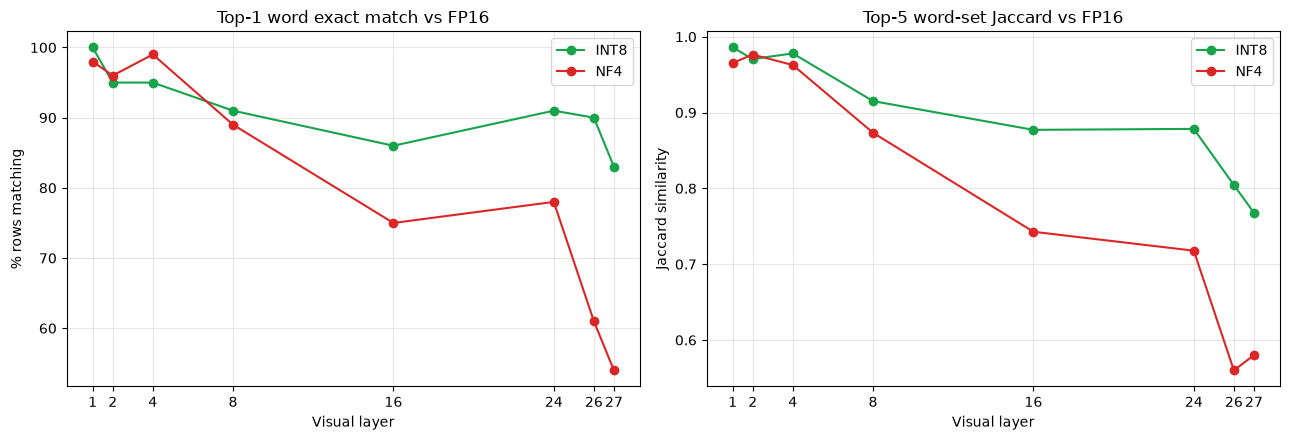

Saved → /Users/praful/myfiles/repos/latentlens/experiment/data/results/eda_neighbor_stability.png


condition,INT8,NF4
layer,,
1,100.0,98.0
2,95.0,96.0
4,95.0,99.0
8,91.0,89.0
16,86.0,75.0
24,91.0,78.0
26,90.0,61.0
27,83.0,54.0


In [5]:
# Neighbor stability vs FP16

def overlap_stats(dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:
    fp = dfs["fp16"].set_index("key")
    rows = []
    for cond in ("int8", "nf4"):
        q = dfs[cond].set_index("key")
        top1_match = (fp["top1_word"] == q["top1_word"])
        jaccard = [
            len(set(a) & set(b)) / len(set(a) | set(b)) if set(a) | set(b) else 1.0
            for a, b in zip(fp["top5_words"], q["top5_words"])
        ]
        tmp = pd.DataFrame({"layer": fp["layer"], "top1_match": top1_match, "jaccard": jaccard})
        for layer, grp in tmp.groupby("layer"):
            rows.append({
                "condition": CONDITION_LABELS[cond],
                "layer": layer,
                "top1_match_pct": 100 * grp["top1_match"].mean(),
                "top5_jaccard": grp["jaccard"].mean(),
            })
    return pd.DataFrame(rows)


stab = overlap_stats(dfs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for cond, grp in stab.groupby("condition"):
    c = "int8" if "INT8" in cond else "nf4"
    axes[0].plot(grp["layer"], grp["top1_match_pct"], marker="o", label=cond, color=COLORS[c])
    axes[1].plot(grp["layer"], grp["top5_jaccard"], marker="o", label=cond, color=COLORS[c])

axes[0].set_title("Top-1 word exact match vs FP16")
axes[0].set_xlabel("Visual layer")
axes[0].set_ylabel("% rows matching")
axes[0].set_xticks(layers)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Top-5 word-set Jaccard vs FP16")
axes[1].set_xlabel("Visual layer")
axes[1].set_ylabel("Jaccard similarity")
axes[1].set_xticks(layers)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out = RESULTS_DIR / "eda_neighbor_stability.png"
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved → {out}")

display(stab.pivot(index="layer", columns="condition", values="top1_match_pct").round(1))

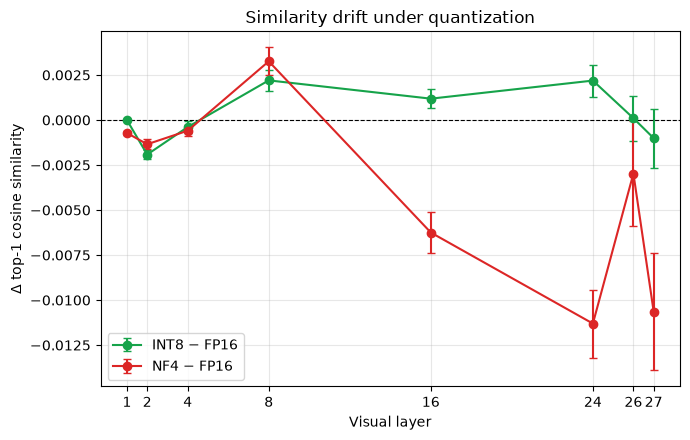

Saved → /Users/praful/myfiles/repos/latentlens/experiment/data/results/eda_sim_drift.png


In [6]:
# Top-1 similarity drift vs FP16

fig, ax = plt.subplots(figsize=(7, 4.5))
fp = dfs["fp16"].set_index("key")

for cond in ("int8", "nf4"):
    q = dfs[cond].set_index("key")
    delta_sim = q["top1_sim"] - fp["top1_sim"]
    by_layer = delta_sim.groupby(q["layer"]).agg(["mean", "sem"])
    ax.errorbar(
        by_layer.index, by_layer["mean"], yerr=by_layer["sem"],
        marker="o", capsize=3, label=f"{CONDITION_LABELS[cond]} − FP16", color=COLORS[cond],
    )

ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Visual layer")
ax.set_ylabel("Δ top-1 cosine similarity")
ax.set_title("Similarity drift under quantization")
ax.set_xticks(layers)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = RESULTS_DIR / "eda_sim_drift.png"
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved → {out}")

/var/folders/wt/nq0pqwh14jzb76hnz0x05sth0000gn/T/ipykernel_48996/2603020911.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


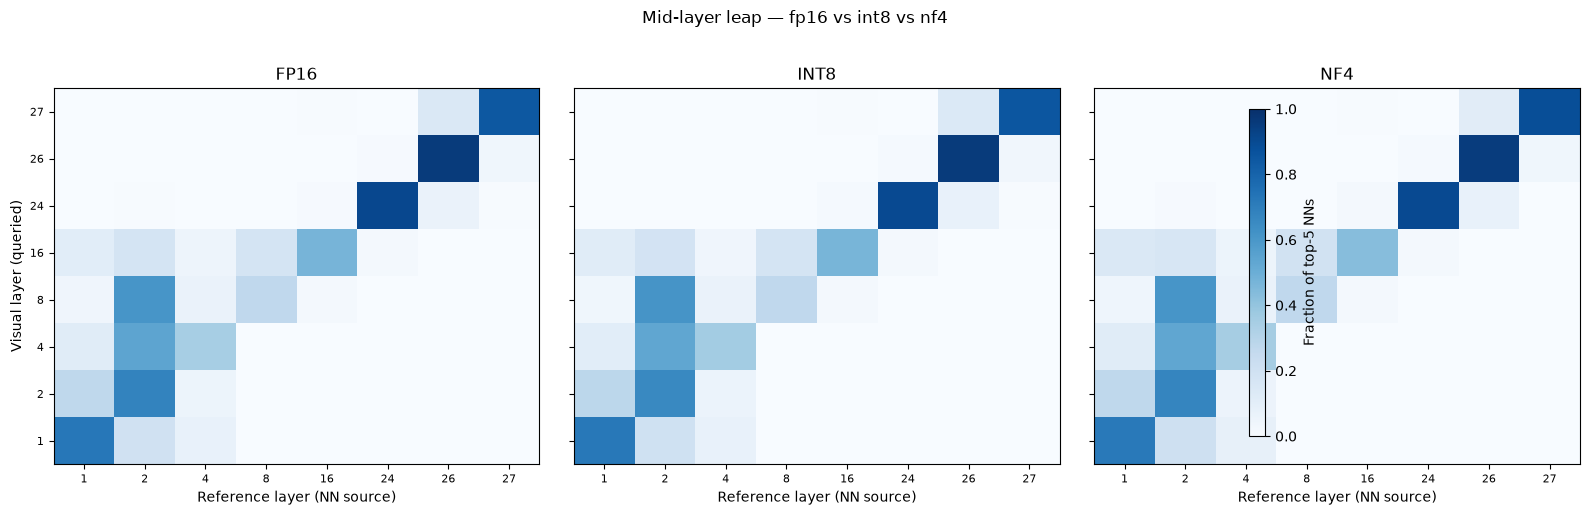

Saved → /Users/praful/myfiles/repos/latentlens/experiment/data/results/eda_mid_layer_leap_compare.png


In [7]:
def mid_layer_leap_matrix(rows: list[dict]) -> tuple[np.ndarray, list[int]]:
    queried_layers = sorted({r["layer"] for r in rows})
    ref_layers = sorted({n["nn_layer"] for r in rows for n in r["top5_results"]})
    all_layers = sorted(set(queried_layers) | set(ref_layers))

    counts: dict[tuple, list] = defaultdict(list)
    for r in rows:
        top5 = [n["nn_layer"] for n in r["top5_results"]]
        vl = r["layer"]
        for rl in ref_layers:
            counts[(vl, rl)].append(top5.count(rl) / len(top5))

    matrix = np.zeros((len(all_layers), len(all_layers)))
    for i, vl in enumerate(all_layers):
        if vl not in queried_layers:
            continue
        for j, rl in enumerate(all_layers):
            vals = counts.get((vl, rl), [])
            matrix[i, j] = np.mean(vals) if vals else 0.0
    return matrix, all_layers


fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, cond in zip(axes, CONDITIONS):
    mat, all_layers = mid_layer_leap_matrix(results[cond])
    im = ax.imshow(mat, aspect="auto", cmap="Blues", vmin=0, vmax=1, origin="lower")
    ax.set_title(CONDITION_LABELS[cond])
    ax.set_xticks(range(len(all_layers)))
    ax.set_xticklabels(all_layers, fontsize=8)
    ax.set_yticks(range(len(all_layers)))
    ax.set_yticklabels(all_layers, fontsize=8)
    if cond == CONDITIONS[0]:
        ax.set_ylabel("Visual layer (queried)")
    ax.set_xlabel("Reference layer (NN source)")

fig.colorbar(im, ax=axes, label="Fraction of top-5 NNs", shrink=0.85)
fig.suptitle("Mid-layer leap — fp16 vs int8 vs nf4", y=1.02)
plt.tight_layout()
out = RESULTS_DIR / "eda_mid_layer_leap_compare.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

In [8]:
# Inspect largest depth shifts (nf4 vs fp16) — candidate hypernym climbs

fp = dfs["fp16"].set_index("key")
nf4 = dfs["nf4"].set_index("key")

merged = fp.join(nf4, lsuffix="_fp", rsuffix="_nf4")
merged["depth_delta"] = merged["mean_depth_nf4"] - merged["mean_depth_fp"]
merged = merged.dropna(subset=["mean_depth_fp", "mean_depth_nf4"])

# biggest drops in depth (more hypernym-like under nf4)
biggest = merged.nsmallest(10, "depth_delta")[
    ["val_idx_fp", "layer_fp", "top1_word_fp", "top1_word_nf4",
     "mean_depth_fp", "mean_depth_nf4", "depth_delta", "top1_sim_fp", "top1_sim_nf4"]
]
print("Top 10 rows with largest depth drop (nf4 more hypernym-like):\n")
display(biggest.round(3))

# rows where top-1 word changed but similarity stayed high
changed = merged[merged["top1_word_fp"] != merged["top1_word_nf4"]].copy()
changed["sim_delta"] = changed["top1_sim_nf4"] - changed["top1_sim_fp"]
print(f"\nTop-1 word changed: {len(changed)}/{len(merged)} rows ({100*len(changed)/len(merged):.1f}%)")
display(changed.nsmallest(8, "depth_delta")[
    ["val_idx_fp", "layer_fp", "top1_word_fp", "top1_word_nf4", "depth_delta", "sim_delta"]
].round(3))

Top 10 rows with largest depth drop (nf4 more hypernym-like):



,val_idx_fp,layer_fp,top1_word_fp,top1_word_nf4,mean_depth_fp,mean_depth_nf4,depth_delta,top1_sim_fp,top1_sim_nf4
key,,,,,,,,,
"(18, 24)",18,24,shizuwakanko,shizuwakanko,10.000,4.0,-6.000,0.338,0.335
"(60, 8)",60,8,caucus,caucus,8.250,4.0,-4.250,0.144,0.147
"(25, 26)",25,26,#,displaying,8.000,4.0,-4.000,0.374,0.338
"(3, 27)",3,27,pigeons,fernlike,12.000,9.0,-3.000,0.466,0.442
"(24, 27)",24,27,patties,[poster,9.500,7.0,-2.500,0.503,0.494
"(7, 26)",7,26,holding,holding,8.750,6.5,-2.250,0.354,0.379
"(22, 26)",22,26,suv,printing,9.000,7.0,-2.000,0.405,0.370
"(58, 27)",58,27,harvest,harvest,11.000,9.0,-2.000,0.369,0.334
"(93, 26)",93,26,teniscourt,turf,5.667,4.0,-1.667,0.350,0.326



Top-1 word changed: 72/427 rows (16.9%)


,val_idx_fp,layer_fp,top1_word_fp,top1_word_nf4,depth_delta,sim_delta
key,,,,,,
"(25, 26)",25,26,#,displaying,-4.000,-0.036
"(3, 27)",3,27,pigeons,fernlike,-3.000,-0.024
"(24, 27)",24,27,patties,[poster,-2.500,-0.009
"(22, 26)",22,26,suv,printing,-2.000,-0.035
"(93, 26)",93,26,teniscourt,turf,-1.667,-0.024
"(40, 24)",40,24,goatherd,petting,-1.500,0.008
"(69, 27)",69,27,umbrela,marisol,-1.500,-0.025
"(79, 27)",79,27,shiba,your,-1.500,-0.041
